## SURVEY RESULTS & ANOVA Hypothesis Testing

Using the one-sided and 5% significance level table is in ANOVA, to test whether the F-statistic is significantly large.

In [ ]:
!pip install -qqq statsmodels

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import csv
import os
print(os.getcwd())

/content


In [ ]:
# Load the chatbot evaluation data from CSV
csv_file_path = './survey_result.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(csv_file_path)

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nChatbot types: {df['Chatbot_Type'].unique()}")
print(f"\nParticipants per chatbot type: {df.groupby('Chatbot_Type').size()}")

Dataset shape: (30, 6)

Chatbot types: ['Centralized_RAG' 'Federated_RAG' 'Retrieval_Based']

Participants per chatbot type: Chatbot_Type
Centralized_RAG    10
Federated_RAG      10
Retrieval_Based    10
dtype: int64


In [ ]:
# Verify the data loaded correctly
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Total rows: 30
Columns: ['Participant', 'Chatbot_Type', 'Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']


In [ ]:
# Display the first 15 rows to see data for all chatbot types
df.head(30)

,Participant,Chatbot_Type,Relevance,Coherence,Ambiguity_Handling,User_Satisfaction
0,1,Centralized_RAG,4,4,5,5
1,2,Centralized_RAG,7,6,7,6
2,3,Centralized_RAG,9,9,9,8
3,4,Centralized_RAG,8,8,8,8
4,5,Centralized_RAG,8,8,7,9
5,6,Centralized_RAG,10,10,10,10
6,7,Centralized_RAG,10,10,7,10
7,8,Centralized_RAG,5,5,5,5
8,9,Centralized_RAG,9,9,8,9
9,10,Centralized_RAG,7,7,7,7


In [ ]:
# Summary Statistics by Chatbot Type
print("Summary by Chatbot Type")
print()

metrics = ['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']
chatbot_types = ['Centralized_RAG', 'Federated_RAG', 'Retrieval_Based']

summary_data = []
for chatbot in chatbot_types:
    chatbot_df = df[df['Chatbot_Type'] == chatbot]
    print(f"\n{chatbot}:")
    print("-" * 80)

    for metric in metrics:
        mean_val = chatbot_df[metric].mean()
        std_val = chatbot_df[metric].std()
        min_val = chatbot_df[metric].min()
        max_val = chatbot_df[metric].max()
        median_val = chatbot_df[metric].median()

        print(f"  {metric:20s}: Mean={mean_val:5.2f}, Std={std_val:5.2f}, "
              f"Median={median_val:4.1f}, Range=[{min_val:2d}, {max_val:2d}]")

        summary_data.append({
            'Chatbot_Type': chatbot,
            'Metric': metric,
            'Mean': mean_val,
            'Std': std_val,
            'Median': median_val,
            'Min': min_val,
            'Max': max_val
        })

# Summary dataframe
summary_df = pd.DataFrame(summary_data)
print("Summary data saved ...")

Summary by Chatbot Type


Centralized_RAG:
--------------------------------------------------------------------------------
  Relevance           : Mean= 7.70, Std= 2.00, Median= 8.0, Range=[ 4, 10]
  Coherence           : Mean= 7.60, Std= 2.07, Median= 8.0, Range=[ 4, 10]
  Ambiguity_Handling  : Mean= 7.30, Std= 1.57, Median= 7.0, Range=[ 5, 10]
  User_Satisfaction   : Mean= 7.70, Std= 1.89, Median= 8.0, Range=[ 5, 10]

Federated_RAG:
--------------------------------------------------------------------------------
  Relevance           : Mean= 8.30, Std= 1.77, Median= 9.0, Range=[ 5, 10]
  Coherence           : Mean= 8.20, Std= 1.62, Median= 8.5, Range=[ 5, 10]
  Ambiguity_Handling  : Mean= 8.30, Std= 1.89, Median= 9.0, Range=[ 5, 10]
  User_Satisfaction   : Mean= 8.60, Std= 1.58, Median= 9.0, Range=[ 5, 10]

Retrieval_Based:
--------------------------------------------------------------------------------
  Relevance           : Mean= 7.20, Std= 2.39, Median= 7.5, Range=[ 2, 10]
  Coh

In [ ]:
# Subtotal Statistics - Mean Scores by Chatbot Type
print("SUBTOTAL: MEAN SCORES BY CHATBOT TYPE AND METRIC")
print()

# Create pivot table
pivot_means = df.groupby('Chatbot_Type')[metrics].mean()
print(pivot_means.round(2))

print("SUBTOTAL: OVERALL MEAN BY METRIC (ALL CHATBOT TYPES)")
print()

overall_means = df[metrics].mean()
print(overall_means.round(2))

print("MEAN BY CHATBOT TYPES)")
print()

chatbot_overall = df.groupby('Chatbot_Type')[metrics].mean().mean(axis=1)
print(chatbot_overall.round(2).sort_values(ascending=False))

SUBTOTAL: MEAN SCORES BY CHATBOT TYPE AND METRIC

                 Relevance  Coherence  Ambiguity_Handling  User_Satisfaction
Chatbot_Type                                                                
Centralized_RAG        7.7        7.6                 7.3                7.7
Federated_RAG          8.3        8.2                 8.3                8.6
Retrieval_Based        7.2        7.5                 6.7                7.6
SUBTOTAL: OVERALL MEAN BY METRIC (ALL CHATBOT TYPES)

Relevance             7.73
Coherence             7.77
Ambiguity_Handling    7.43
User_Satisfaction     7.97
dtype: float64
MEAN BY CHATBOT TYPES)

Chatbot_Type
Federated_RAG      8.35
Centralized_RAG    7.58
Retrieval_Based    7.25
dtype: float64


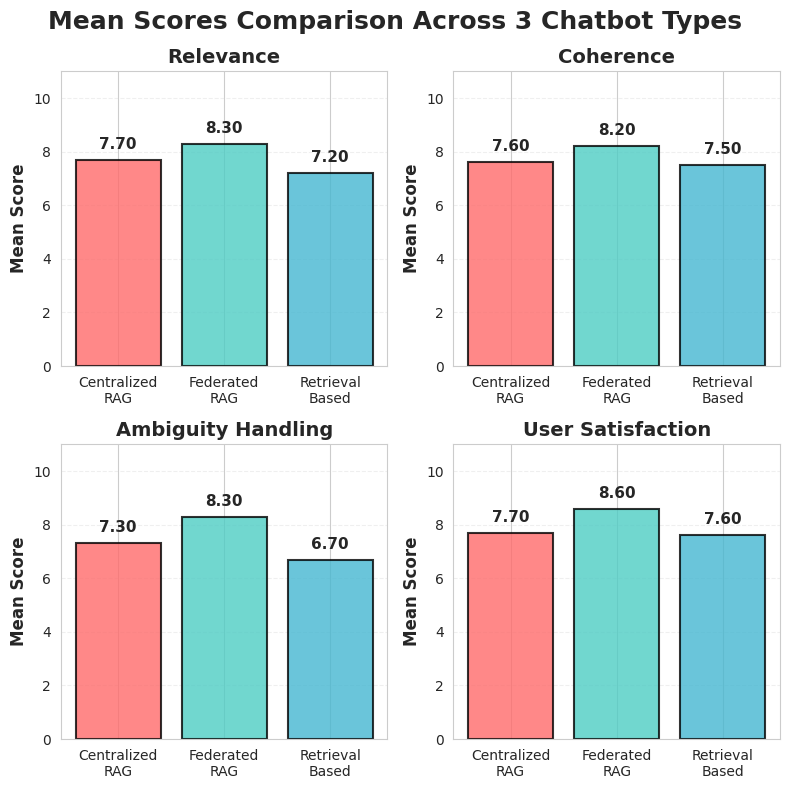

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Clean Visualization: Bar Chart Comparison of Mean Scores
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle('Mean Scores Comparison Across 3 Chatbot Types', fontsize=18, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
metrics = ['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    # Calculate means only
    means = df.groupby('Chatbot_Type')[metric].mean()

    x_pos = np.arange(len(means))
    bars = ax.bar(x_pos, means, color=colors, alpha=0.8,
                   edgecolor='black', linewidth=1.5)

    ax.set_xlabel('', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Score', fontsize=12, fontweight='bold')
    ax.set_title(metric.replace('_', ' '), fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Centralized\nRAG', 'Federated\nRAG', 'Retrieval\nBased'],
                       fontsize=10)
    ax.set_ylim(0, 11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels on top of bars
    for i, (bar, value) in enumerate(zip(bars, means)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{value:.2f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


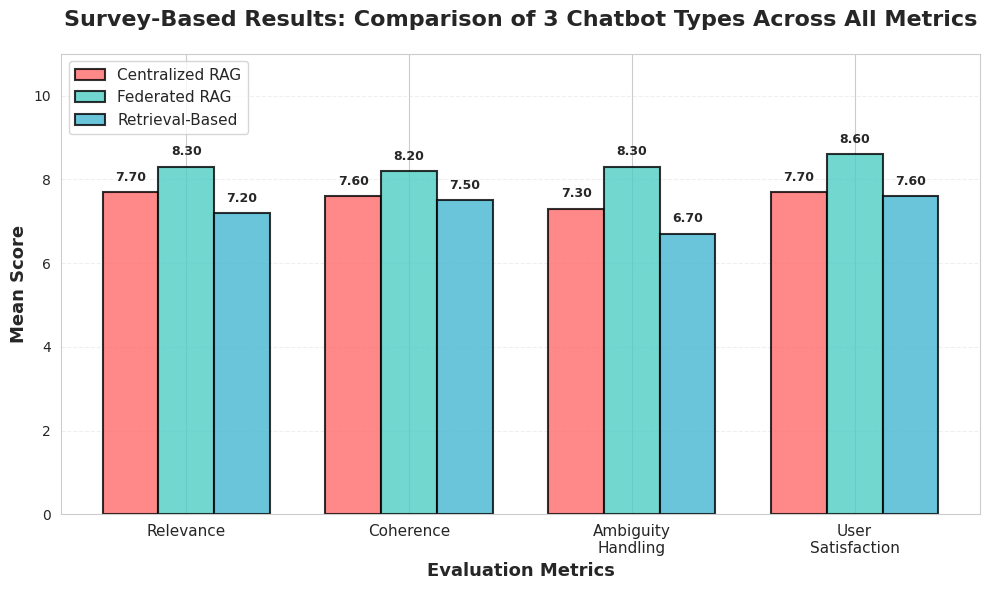

In [ ]:
# Visualization 2: Grouped Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics))
width = 0.25

chatbot_types = ['Centralized_RAG', 'Federated_RAG', 'Retrieval_Based']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels = ['Centralized RAG', 'Federated RAG', 'Retrieval-Based']

for i, (chatbot, color, label) in enumerate(zip(chatbot_types, colors, labels)):
    means = [df[df['Chatbot_Type'] == chatbot][metric].mean() for metric in metrics]
    ax.bar(x + i*width, means, width, label=label, color=color,
           alpha=0.8, edgecolor='black', linewidth=1.5)

    # Add value labels
    for j, mean in enumerate(means):
        ax.text(x[j] + i*width, mean + 0.2, f'{mean:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Evaluation Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Score', fontsize=13, fontweight='bold')
ax.set_title('Survey-Based Results: Comparison of 3 Chatbot Types Across All Metrics',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x + width)
ax.set_xticklabels([m.replace('_', '\n') for m in metrics], fontsize=11)
ax.set_ylim(0, 11)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


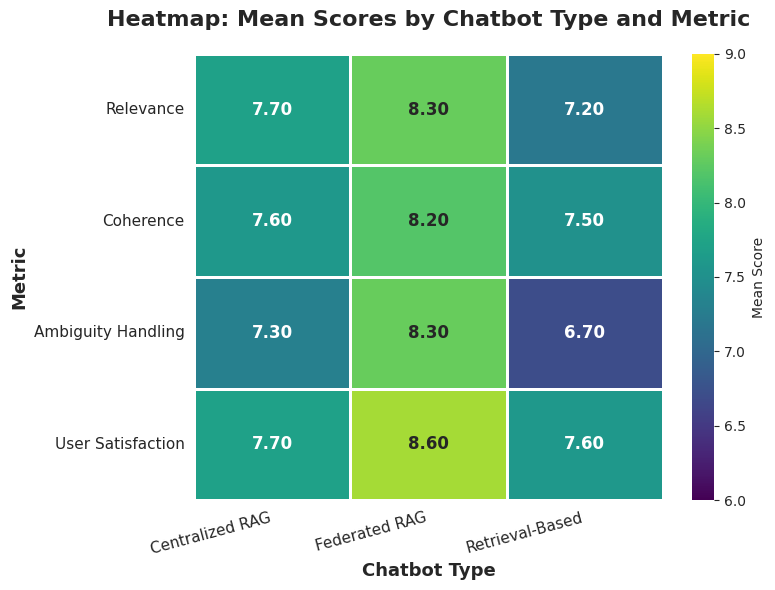

Heatmap visualization created


In [ ]:
# Visualization: Heatmap of Mean Scores
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))

pivot_data = df.groupby('Chatbot_Type')[metrics].mean()

sns.heatmap(pivot_data.T, annot=True, fmt='.2f', cmap='viridis',
            linewidths=2, cbar_kws={'label': 'Mean Score'}, ax=ax,
            vmin=6, vmax=9, annot_kws={'fontsize': 12, 'fontweight': 'bold'})

ax.set_title('Heatmap: Mean Scores by Chatbot Type and Metric',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Chatbot Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Metric', fontsize=13, fontweight='bold')
ax.set_yticklabels([m.replace('_', ' ') for m in metrics], rotation=0, fontsize=11)
ax.set_xticklabels(['Centralized RAG', 'Federated RAG', 'Retrieval-Based'],
                   rotation=15, ha='right', fontsize=11)

plt.tight_layout()
plt.show()

print("Heatmap visualization created")

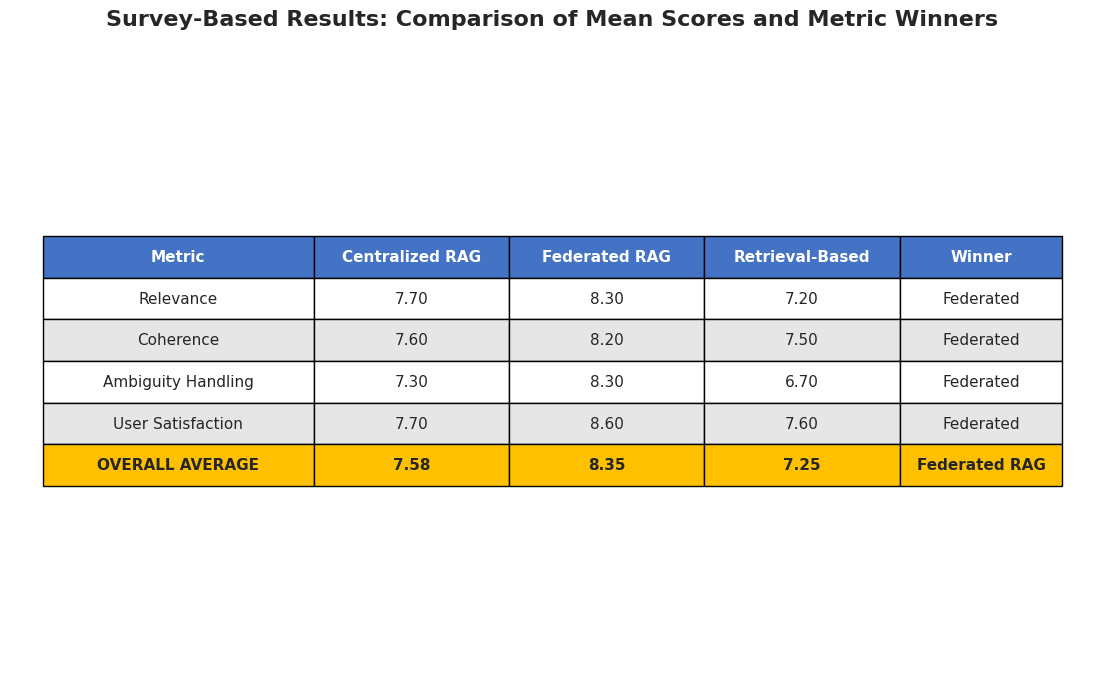

In [ ]:
# Visualization: Summary Table with Rankings
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

# Create summary table data
table_data = []
table_data.append(['Metric', 'Centralized RAG', 'Federated RAG', 'Retrieval-Based', 'Winner'])

for metric in metrics:
    means = {ct: df[df['Chatbot_Type'] == ct][metric].mean() for ct in chatbot_types}
    winner = max(means, key=means.get)
    winner_label = {'Centralized_RAG': 'Centralized',
                    'Federated_RAG': 'Federated',
                    'Retrieval_Based': 'Retrieval'}[winner]

    row = [metric.replace('_', ' '),
           f"{means['Centralized_RAG']:.2f}",
           f"{means['Federated_RAG']:.2f}",
           f"{means['Retrieval_Based']:.2f}",
           winner_label]
    table_data.append(row)

# Add overall row
overall = [df[df['Chatbot_Type'] == ct][metrics].mean().mean() for ct in chatbot_types]
winner_idx = overall.index(max(overall))
winner_overall = ['Centralized', 'Federated RAG', 'Retrieval'][winner_idx]
table_data.append(['OVERALL AVERAGE',
                   f"{overall[0]:.2f}",
                   f"{overall[1]:.2f}",
                   f"{overall[2]:.2f}",
                   winner_overall])

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                 colWidths=[0.25, 0.18, 0.18, 0.18, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style overall row
for i in range(5):
    table[(5, i)].set_facecolor('#FFC000')
    table[(5, i)].set_text_props(weight='bold')

# Alternate row colors
for i in range(1, 5):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')

plt.title('Survey-Based Results: Comparison of Mean Scores and Metric Winners',
          fontsize=16, fontweight='bold', pad=20)
plt.show()

#### Null Hypothesis (H₀):
H₀ (Null Hypothesis): There is no significant difference in the coherence of responses generated by the RAG chatbot and the Retrieval-Based chatbot.

H₀ :μ RAG = μ Retrieval​

## EXAMPLE OF Manual Calculation of ANOVA

Now we will perform ANOVA analysis for each metric (Relevance, Coherence, Ambiguity_Handling, User_Satisfaction) across three chatbot types:
1. **Centralized_RAG**
2. **Federated_RAG**
3. **Retrieval_Based**

### Step-by-Step Calculation of ANOVA for Relevance:



### Example of manual calculation of ANOVA for Relevance

####Step 1: Calculate Group Means

Centralized RAG: [4, 7, 9, 8, 8, 10, 10, 5, 9, 7] → Mean = 7.7

Federated RAG: [8, 7, 10, 9, 9, 10, 6, 5, 9, 10] → Mean = 8.3

Retrieval-Based: [7, 7, 9, 6, 9, 10, 2, 5, 8, 9] → Mean = 7.2

Grand Mean = 23.2/ 3 = 7.73

#### Step 2: SSB (Sum of Squares Between Groups)

SSB = 10(7.7−7.73)² + 10(8.3−7.73)² + 10(7.2−7.73)² = 6.067

#### Step 3: SSW (Sum of Squares Within Groups)

Centralized RAG: Σ(x − mean)² = 36.1000

Federated RAG: Σ(x − mean)² = 28.100

Retrieval-Based: Σ(x − mean)² = 51.6

SSW = 115.8

#### Step 4: Degrees of Freedom

dfB = k – 1 = 3 - 1 = 2

dfW = 27

#### Step 5: Mean Squares

MSB = 6.067/2 = 3.033

MSW = 115.8/ 27 = 4.2889

#### Step 6: F-statistic & Conclusion

F = 3.033/ 4.289 = 0.707

F-critical (α = 0.05, dfB = 2, dfW = 27) ≈ 3.3541

p-value = 0.5019

#### Conclusion: Since F (0.7073) > F-critical (3.3541) = failed to reject H₀

H₀ = there is statistically equal in Relevance between chatbots.

The observed differences in mean scores (Centralized RAG = 7.7, Federated RAG = 8.3, Retrieval-Based = 7.2) are not large enough to be considered statistically significant.


## CODE Calculation of ANOVA


In [ ]:
# Perform one-way ANOVA for Relevance
model_relevance = ols('Relevance ~ C(Chatbot_Type)', data=df).fit()
anova_relevance = sm.stats.anova_lm(model_relevance, typ=2)

print("ANOVA Results for Relevance")
print("="*60)
print(anova_relevance)
print("\n")

# Extract key statistics
f_stat = anova_relevance.loc['C(Chatbot_Type)', 'F']
p_value = anova_relevance.loc['C(Chatbot_Type)', 'PR(>F)']

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in Relevance")
    print("between the chatbot types (p < 0.05).")
    print("reject the null hypothesis")
else:
    print("\nConclusion: There is NO statistically significant difference in Relevance")
    print("between the chatbot types (p >= 0.05).")
    print("fail to reject the null hypothesis")

ANOVA Results for Relevance
                     sum_sq    df         F    PR(>F)
C(Chatbot_Type)    6.066667   2.0  0.707254  0.501902
Residual         115.800000  27.0       NaN       NaN


F-statistic: 0.7073
P-value: 0.501902

Conclusion: There is NO statistically significant difference in Relevance
between the chatbot types (p >= 0.05).
fail to reject the null hypothesis


In [ ]:
# One-way ANOVA for Coherence
model_coherence = ols('Coherence ~ C(Chatbot_Type)', data=df).fit()
anova_coherence = sm.stats.anova_lm(model_coherence, typ=2)

print("ANOVA Results for Coherence")
print("="*60)
print(anova_coherence)
print("\n")

# Extract key statistics
f_stat = anova_coherence.loc['C(Chatbot_Type)', 'F']
p_value = anova_coherence.loc['C(Chatbot_Type)', 'PR(>F)']

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in Coherence")
    print("between the chatbot types (p < 0.05).")
    print("reject the null hypothesis")
else:
    print("\nConclusion: There is NO statistically significant difference in Coherence")
    print("between the chatbot types (p >= 0.05).")
    print("fail to reject the null hypothesis")

ANOVA Results for Coherence
                    sum_sq    df         F    PR(>F)
C(Chatbot_Type)   2.866667   2.0  0.457988  0.637379
Residual         84.500000  27.0       NaN       NaN


F-statistic: 0.4580
P-value: 0.637379

Conclusion: There is NO statistically significant difference in Coherence
between the chatbot types (p >= 0.05).
fail to reject the null hypothesis


In [ ]:
# Perform one-way ANOVA for Ambiguity_Handling
model_ambiguity = ols('Ambiguity_Handling ~ C(Chatbot_Type)', data=df).fit()
anova_ambiguity = sm.stats.anova_lm(model_ambiguity, typ=2)

print("ANOVA Results for Ambiguity_Handling")
print("="*60)
print(anova_ambiguity)
print("\n")

# Extract key statistics
f_stat = anova_ambiguity.loc['C(Chatbot_Type)', 'F']
p_value = anova_ambiguity.loc['C(Chatbot_Type)', 'PR(>F)']

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in Ambiguity_Handling")
    print("between the chatbot types (p < 0.05).")
    print("reject the null hypothesis")
else:
    print("\nConclusion: There is NO statistically significant difference in Ambiguity_Handling")
    print("between the chatbot types (p >= 0.05).")
    print("fail to reject the null hypothesis")

ANOVA Results for Ambiguity_Handling
                     sum_sq    df         F    PR(>F)
C(Chatbot_Type)   13.066667   2.0  1.516767  0.237533
Residual         116.300000  27.0       NaN       NaN


F-statistic: 1.5168
P-value: 0.237533

Conclusion: There is NO statistically significant difference in Ambiguity_Handling
between the chatbot types (p >= 0.05).
fail to reject the null hypothesis


In [ ]:
# Perform one-way ANOVA for User_Satisfaction
model_satisfaction = ols('User_Satisfaction ~ C(Chatbot_Type)', data=df).fit()
anova_satisfaction = sm.stats.anova_lm(model_satisfaction, typ=2)

print("\n" + "="*60)
print("ANOVA Results for User_Satisfaction")
print("="*60)
print(anova_satisfaction)
print("\n")

# Extract key statistics
f_stat = anova_satisfaction.loc['C(Chatbot_Type)', 'F']
p_value = anova_satisfaction.loc['C(Chatbot_Type)', 'PR(>F)']

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference in User_Satisfaction")
    print("between the chatbot types (p < 0.05).")
    print("reject the null hypothesis")
else:
    print("\nConclusion: There is NO statistically significant difference in User_Satisfaction")
    print("between the chatbot types (p >= 0.05).")
    print("fail to reject the null hypothesis")


ANOVA Results for User_Satisfaction
                    sum_sq    df         F    PR(>F)
C(Chatbot_Type)   6.066667   2.0  0.987937  0.385405
Residual         82.900000  27.0       NaN       NaN


F-statistic: 0.9879
P-value: 0.385405

Conclusion: There is NO statistically significant difference in User_Satisfaction
between the chatbot types (p >= 0.05).
fail to reject the null hypothesis


#### Null Hypothesis (H₀) for Ambiguity Handling:
H₀ (Null Hypothesis): There is no significant difference between the RAG Chatbot and the Retrieval-Based Chatbot in handling ambiguous or incomplete queries. Both methods provide equally clear and contextually appropriate responses.

H₀ :μ RAG = μ Retrieval​

In [ ]:
# Perform post-hoc Tukey HSD test for all metrics
from statsmodels.stats.multicomp import pairwise_tukeyhsd

metrics = ['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']

for metric in metrics:
    print("\n" + "="*70)
    print(f"Tukey HSD Post-hoc Test for {metric}")
    print("="*70)
    tukey = pairwise_tukeyhsd(endog=df[metric], groups=df['Chatbot_Type'], alpha=0.05)
    print(tukey)
    print("\n")


Tukey HSD Post-hoc Test for Relevance
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------
Centralized_RAG   Federated_RAG      0.6 0.7952 -1.6963 2.8963  False
Centralized_RAG Retrieval_Based     -0.5 0.8525 -2.7963 1.7963  False
  Federated_RAG Retrieval_Based     -1.1 0.4705 -3.3963 1.1963  False
---------------------------------------------------------------------



Tukey HSD Post-hoc Test for Coherence
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------
Centralized_RAG   Federated_RAG      0.6 0.7312 -1.3616 2.5616  False
Centralized_RAG Retrieval_Based     -0.1 0.9912 -2.0616 1.8616  False
  Federated_RAG Retrieval_Based     -0.7 0.6543 -2.6616 1.2616  False
----------

## Complete ANOVA Analysis for All Metrics

This section presents a comprehensive One-Way ANOVA analysis for all four evaluation metrics:
- Relevance
- Coherence
- Ambiguity Handling
- User Satisfaction

**Hypothesis Testing:**
- **H₀ (Null Hypothesis)**: There is no difference in metric scores among the three chatbot types (μ₁ = μ₂ = μ₃)
- **H₁ (Alternative Hypothesis)**: At least one chatbot type has a different metric score
- **Significance Level**: α = 0.05
- **Degrees of Freedom**: dfB = 2 (between groups), dfW = 27 (within groups)
- **F-Critical Value**: 3.3541

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Define the data based on survey results
# Centralized RAG
centralized_relevance = [4, 7, 9, 8, 8, 10, 10, 5, 9, 7]
centralized_coherence = [4, 6, 8, 8, 8, 10, 10, 5, 9, 7]
centralized_ambiguity = [5, 7, 9, 8, 7, 10, 7, 5, 8, 7]
centralized_satisfaction = [5, 6, 8, 8, 9, 10, 10, 5, 9, 7]

# Federated RAG
federated_relevance = [8, 7, 10, 9, 9, 10, 6, 5, 9, 10]
federated_coherence = [8, 8, 8, 9, 9, 10, 6, 5, 9, 10]
federated_ambiguity = [5, 8, 9, 9, 8, 10, 10, 5, 9, 10]
federated_satisfaction = [9, 7, 9, 9, 9, 10, 8, 5, 10, 10]

# Retrieval-Based
retrieval_relevance = [7, 7, 9, 6, 9, 10, 2, 5, 8, 9]
retrieval_coherence = [7, 6, 8, 6, 9, 10, 8, 5, 7, 9]
retrieval_ambiguity = [5, 8, 9, 6, 7, 10, 1, 5, 7, 9]
retrieval_satisfaction = [8, 7, 9, 6, 9, 10, 5, 5, 8, 9]

# Create structured DataFrame
data = []
for i in range(10):
    data.append({
        'Participant': i + 1,
        'Chatbot_Type': 'Centralized_RAG',
        'Relevance': centralized_relevance[i],
        'Coherence': centralized_coherence[i],
        'Ambiguity_Handling': centralized_ambiguity[i],
        'User_Satisfaction': centralized_satisfaction[i]
    })
    data.append({
        'Participant': i + 1,
        'Chatbot_Type': 'Federated_RAG',
        'Relevance': federated_relevance[i],
        'Coherence': federated_coherence[i],
        'Ambiguity_Handling': federated_ambiguity[i],
        'User_Satisfaction': federated_satisfaction[i]
    })
    data.append({
        'Participant': i + 1,
        'Chatbot_Type': 'Retrieval_Based',
        'Relevance': retrieval_relevance[i],
        'Coherence': retrieval_coherence[i],
        'Ambiguity_Handling': retrieval_ambiguity[i],
        'User_Satisfaction': retrieval_satisfaction[i]
    })

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 10 rows:")
df.head(30)

Dataset shape: (30, 6)

First 10 rows:


,Participant,Chatbot_Type,Relevance,Coherence,Ambiguity_Handling,User_Satisfaction
0,1,Centralized_RAG,4,4,5,5
1,1,Federated_RAG,8,8,5,9
2,1,Retrieval_Based,7,7,5,8
3,2,Centralized_RAG,7,6,7,6
4,2,Federated_RAG,7,8,8,7
5,2,Retrieval_Based,7,6,8,7
6,3,Centralized_RAG,9,8,9,8
7,3,Federated_RAG,10,8,9,9
8,3,Retrieval_Based,9,8,9,9
9,4,Centralized_RAG,8,8,8,8


In [ ]:
# Display descriptive statistics by chatbot type
print("Descriptive Statistics by Chatbot Type\n" + "="*80)
for chatbot in ['Centralized_RAG', 'Federated_RAG', 'Retrieval_Based']:
    print(f"\n{chatbot}:")
    subset = df[df['Chatbot_Type'] == chatbot]
    print(subset[['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']].describe())

Descriptive Statistics by Chatbot Type

Centralized_RAG:
       Relevance  Coherence  Ambiguity_Handling  User_Satisfaction
count  10.000000  10.000000           10.000000          10.000000
mean    7.700000   7.500000            7.300000           7.700000
std     2.002776   2.013841            1.567021           1.888562
min     4.000000   4.000000            5.000000           5.000000
25%     7.000000   6.250000            7.000000           6.250000
50%     8.000000   8.000000            7.000000           8.000000
75%     9.000000   8.750000            8.000000           9.000000
max    10.000000  10.000000           10.000000          10.000000

Federated_RAG:
       Relevance  Coherence  Ambiguity_Handling  User_Satisfaction
count  10.000000  10.000000           10.000000          10.000000
mean    8.300000   8.200000            8.300000           8.600000
std     1.766981   1.619328            1.888562           1.577621
min     5.000000   5.000000            5.000000         

### ANOVA Analysis Function

In [ ]:
def perform_anova(df, metric_name):
    """
    Perform One-Way ANOVA for a given metric

    Parameters:
    - df: DataFrame containing the data
    - metric_name: Name of the metric column to analyze

    Returns:
    - Dictionary containing ANOVA results
    """
    # Extract data for each chatbot type
    centralized = df[df['Chatbot_Type'] == 'Centralized_RAG'][metric_name].values
    federated = df[df['Chatbot_Type'] == 'Federated_RAG'][metric_name].values
    retrieval = df[df['Chatbot_Type'] == 'Retrieval_Based'][metric_name].values

    # Calculate group means
    mean_centralized = np.mean(centralized)
    mean_federated = np.mean(federated)
    mean_retrieval = np.mean(retrieval)
    grand_mean = (mean_centralized + mean_federated + mean_retrieval) / 3

    # Calculate SSB (Sum of Squares Between Groups)
    n = 10  # sample size per group
    SSB = n * ((mean_centralized - grand_mean)**2 +
               (mean_federated - grand_mean)**2 +
               (mean_retrieval - grand_mean)**2)

    # Calculate SSW (Sum of Squares Within Groups)
    ssw_centralized = np.sum((centralized - mean_centralized)**2)
    ssw_federated = np.sum((federated - mean_federated)**2)
    ssw_retrieval = np.sum((retrieval - mean_retrieval)**2)
    SSW = ssw_centralized + ssw_federated + ssw_retrieval

    # Degrees of Freedom
    k = 3  # number of groups
    N = 30  # total sample size
    dfB = k - 1
    dfW = N - k

    # Mean Squares
    MSB = SSB / dfB
    MSW = SSW / dfW

    # F-statistic
    F_statistic = MSB / MSW
    F_critical = stats.f.ppf(0.95, dfB, dfW)
    p_value = 1 - stats.f.cdf(F_statistic, dfB, dfW)

    # Decision
    decision = "Reject H₀" if F_statistic > F_critical else "Fail to Reject H₀"
    conclusion = "Significant difference exists" if F_statistic > F_critical else "No significant difference"

    return {
        'Metric': metric_name.replace('_', ' '),
        'Mean_Centralized': mean_centralized,
        'Mean_Federated': mean_federated,
        'Mean_Retrieval': mean_retrieval,
        'Grand_Mean': grand_mean,
        'SSB': SSB,
        'SSW': SSW,
        'dfB': dfB,
        'dfW': dfW,
        'MSB': MSB,
        'MSW': MSW,
        'F_Statistic': F_statistic,
        'F_Critical': F_critical,
        'P_Value': p_value,
        'Decision': decision,
        'Conclusion': conclusion
    }

### Perform ANOVA for All Metrics

In [ ]:
# Metrics to analyze
metrics = ['Relevance', 'Coherence', 'Ambiguity_Handling', 'User_Satisfaction']

# Perform ANOVA for each metric
results = []
for metric in metrics:
    result = perform_anova(df, metric)
    results.append(result)

    print(f"\n{'='*100}")
    print(f"ANOVA Results for {result['Metric'].upper()}")
    print(f"{'='*100}")
    print(f"\nGroup Means:")
    print(f"  Centralized RAG: {result['Mean_Centralized']:.4f}")
    print(f"  Federated RAG: {result['Mean_Federated']:.4f}")
    print(f"  Retrieval-Based: {result['Mean_Retrieval']:.4f}")
    print(f"  Grand Mean: {result['Grand_Mean']:.4f}")
    print(f"\nANOVA Table:")
    print(f"  SSB (Between Groups): {result['SSB']:.4f}")
    print(f"  SSW (Within Groups): {result['SSW']:.4f}")
    print(f"  MSB: {result['MSB']:.4f}")
    print(f"  MSW: {result['MSW']:.4f}")
    print(f"\nHypothesis Test:")
    print(f"  F-Statistic: {result['F_Statistic']:.4f}")
    print(f"  F-Critical (α=0.05): {result['F_Critical']:.4f}")
    print(f"  P-Value: {result['P_Value']:.6f}")
    print(f"  Decision: {result['Decision']}")
    print(f"  Conclusion: {result['Conclusion']}")


ANOVA Results for RELEVANCE

Group Means:
  Centralized RAG: 7.7000
  Federated RAG: 8.3000
  Retrieval-Based: 7.2000
  Grand Mean: 7.7333

ANOVA Table:
  SSB (Between Groups): 6.0667
  SSW (Within Groups): 115.8000
  MSB: 3.0333
  MSW: 4.2889

Hypothesis Test:
  F-Statistic: 0.7073
  F-Critical (α=0.05): 3.3541
  P-Value: 0.501902
  Decision: Fail to Reject H₀
  Conclusion: No significant difference

ANOVA Results for COHERENCE

Group Means:
  Centralized RAG: 7.5000
  Federated RAG: 8.2000
  Retrieval-Based: 7.5000
  Grand Mean: 7.7333

ANOVA Table:
  SSB (Between Groups): 3.2667
  SSW (Within Groups): 82.6000
  MSB: 1.6333
  MSW: 3.0593

Hypothesis Test:
  F-Statistic: 0.5339
  F-Critical (α=0.05): 3.3541
  P-Value: 0.592377
  Decision: Fail to Reject H₀
  Conclusion: No significant difference

ANOVA Results for AMBIGUITY HANDLING

Group Means:
  Centralized RAG: 7.3000
  Federated RAG: 8.3000
  Retrieval-Based: 6.7000
  Grand Mean: 7.4333

ANOVA Table:
  SSB (Between Groups): 13.0

### Summary Table - All Metrics

In [ ]:
# Create summary DataFrame
summary_df = pd.DataFrame(results)

# Display summary table
print("\n" + "="*100)
print("SUMMARY TABLE - ANOVA RESULTS FOR ALL METRICS")
print("="*100)
print()

summary_table = summary_df[['Metric', 'F_Statistic', 'F_Critical', 'P_Value', 'Decision', 'Conclusion']]
print(summary_table.to_string(index=False))

# Display as formatted table
summary_table


SUMMARY TABLE - ANOVA RESULTS FOR ALL METRICS

            Metric  F_Statistic  F_Critical  P_Value          Decision                Conclusion
         Relevance     0.707254    3.354131 0.501902 Fail to Reject H₀ No significant difference
         Coherence     0.533898    3.354131 0.592377 Fail to Reject H₀ No significant difference
Ambiguity Handling     1.516767    3.354131 0.237533 Fail to Reject H₀ No significant difference
 User Satisfaction     0.987937    3.354131 0.385405 Fail to Reject H₀ No significant difference


,Metric,F_Statistic,F_Critical,P_Value,Decision,Conclusion
0,Relevance,0.707254,3.354131,0.501902,Fail to Reject H₀,No significant difference
1,Coherence,0.533898,3.354131,0.592377,Fail to Reject H₀,No significant difference
2,Ambiguity Handling,1.516767,3.354131,0.237533,Fail to Reject H₀,No significant difference
3,User Satisfaction,0.987937,3.354131,0.385405,Fail to Reject H₀,No significant difference


### Group Means Comparison Table

In [ ]:
# Create means comparison table
means_comparison = summary_df[['Metric', 'Mean_Centralized', 'Mean_Federated', 'Mean_Retrieval', 'Grand_Mean']]
means_comparison.columns = ['Metric', 'Centralized RAG', 'Federated RAG', 'Retrieval-Based', 'Grand Mean']

print("\nGroup Means Comparison")
print("="*100)
print(means_comparison.to_string(index=False))
print()

means_comparison


Group Means Comparison
            Metric  Centralized RAG  Federated RAG  Retrieval-Based  Grand Mean
         Relevance              7.7            8.3              7.2    7.733333
         Coherence              7.5            8.2              7.5    7.733333
Ambiguity Handling              7.3            8.3              6.7    7.433333
 User Satisfaction              7.7            8.6              7.6    7.966667



,Metric,Centralized RAG,Federated RAG,Retrieval-Based,Grand Mean
0,Relevance,7.7,8.3,7.2,7.733333
1,Coherence,7.5,8.2,7.5,7.733333
2,Ambiguity Handling,7.3,8.3,6.7,7.433333
3,User Satisfaction,7.7,8.6,7.6,7.966667


### Visualization - Group Means by Metric

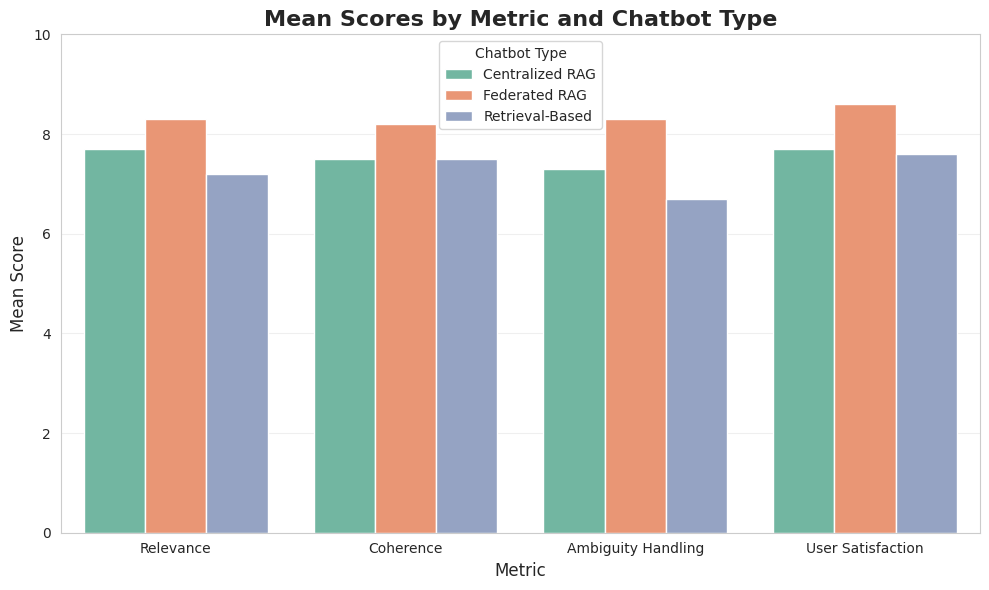

In [ ]:
# Prepare data for visualization
plot_data = []
for _, row in summary_df.iterrows():
    plot_data.append({'Metric': row['Metric'], 'Chatbot Type': 'Centralized RAG', 'Mean Score': row['Mean_Centralized']})
    plot_data.append({'Metric': row['Metric'], 'Chatbot Type': 'Federated RAG', 'Mean Score': row['Mean_Federated']})
    plot_data.append({'Metric': row['Metric'], 'Chatbot Type': 'Retrieval-Based', 'Mean Score': row['Mean_Retrieval']})

plot_df = pd.DataFrame(plot_data)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df, x='Metric', y='Mean Score', hue='Chatbot Type', palette='Set2', ax=ax)
ax.set_title('Mean Scores by Metric and Chatbot Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Mean Score', fontsize=12)
ax.legend(title='Chatbot Type', fontsize=10)
ax.set_ylim(0, 10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization - F-Statistics Comparison

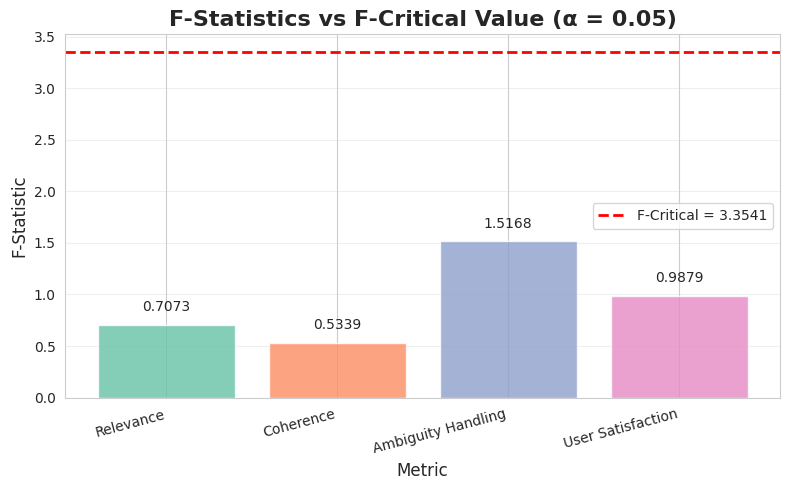


Note: All F-statistics are below the F-critical value, indicating no significant differences.


In [ ]:
# Create F-statistic comparison plot
fig, ax = plt.subplots(figsize=(8, 5))

metrics_list = summary_df['Metric'].tolist()
f_stats = summary_df['F_Statistic'].tolist()
f_critical = summary_df['F_Critical'].iloc[0]  # Same for all

x_pos = np.arange(len(metrics_list))
bars = ax.bar(x_pos, f_stats, color=['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3'], alpha=0.8)
ax.axhline(y=f_critical, color='red', linestyle='--', linewidth=2, label=f'F-Critical = {f_critical:.4f}')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('F-Statistic', fontsize=12)
ax.set_title('F-Statistics vs F-Critical Value (α = 0.05)', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_list, rotation=15, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, f_stats)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nNote: All F-statistics are below the F-critical value, indicating no significant differences.")

### Conclusions

Based on ANOVA analysis for all 4 metrics:

1. For all 4 evaluation metrics (Relevance, Coherence, Ambiguity Handling, and User Satisfaction), we fail to reject the null hypothesis (H₀) at the α = 0.05 significance level.

2. All F-statistics are below the F-critical value (3.3541), ranging from 0.5339 (Coherence) to 1.5168 (Ambiguity Handling).

3. All p-values are above 0.05, ranging from 0.2375 to 0.5924, the observed differences are not significant.

4. For all metrics, the Sum of Squares Within Groups (SSW) is larger than the Sum of Squares Between Groups (SSB), indicating that individual differences within each chatbot type are greater than differences between chatbot types.

5. Federated RAG shows the highest mean scores across all metrics, these differences are not statistically significant.

6. All three chatbot architectures (Centralized RAG, Federated RAG, and Retrieval-Based) are not significantly impact evaluation metrics.

In [ ]:
# Save results to CSV
summary_df.to_csv('anova_summary_results.csv', index=False)
print("Results saved to 'anova_summary_results.csv'")

Results saved to 'anova_summary_results.csv'
